Выполнил: Рябков Александр, P3123

# Предсказание дефолта по кредиту

Многие люди берут кредит в банке. Некоторые не отдают. Если просрочка по кредиту больше 90 дней, банк считает, по данному кредиту произошел дефолт, то есть клиент не в состоянии его отдать.

Одна из первых задач, которую решало машинное обучение в банках, - предсказание дефолта.
Нужно по данным, которые предоставил потенциальный заемщик, определить, будет у него дефолт или нет.

Задача предсказания дефолта - задача классификации, а результат работы модели для конкретного клиента - предсказать произойдет дефолт или нет.
В этой тетради мы рассмотрим вопрос измерения качества работы обученных
классификаторов. На примерах мы опишем различные метрики качества и способы
их подсчёта. Также обратим внимание на адекватность их использования в типичных
практических кейсах.

<img src="https://drive.google.com/uc?id=1jQX02vTP_BKJIRPamIDRQ2U1Ub1NONNH" alt="Drawing" style="width: 50px;" width="360"/>

Мы попробуем на данных из Kaggle соревнования _"Give me some credit"_ обучить модель машинного обучения, которая будет предсказывать дефолт.
https://www.kaggle.com/c/GiveMeSomeCredit#description

**Бизнес-постановка задачи**

Банк по анкетным данным оценивает вероятность того, что для конкретного клиента произойдет дефолт.
Применение модели ясно:
* мы хотим выдавать кредиты только хорошим заемщикам, которые отдадут кредит.

**Постановка задачи анализа данных**

Целью данной задачи является построение модели *классификации дефолтов*: на вход модель будет принимать данные о клиенте, а на выходе она должна работать в двух режимах:
* выдавать вероятность дефолта для данного клиента,
* выдавать правильный с точки зрения модели класс клиента (есть у него дефолт или нет).

Обучать модель мы будем по данным с платформы kaggle.

**Обзор доступных данных**

В выборке N наблюдений и 11 переменных, одна из которых - целевая.
Таким образом, про каждого из N клиентов мы знаем значения 11 их характеристик (возраст, доход в месяц), в том числе значение целевой переменной: есть ли у клиента сейчас просрочка более 90 дней.

Выборка была разбита на две части для обучения и для тестирования модели.

**Доступные признаки**

Данные содержат два типа переменных:

* Целевая: **SeriousDlqin2yrs**, есть ли просрочка 90 дней и более
* Остальные переменные: 10 переменных, могут использоваться для прогноза целевой переменной.

| Имя столбца        | Значение |
| :-------------: |:-------------:|
| SeriousDlqin2yrs      | **Целевая переменная:** Есть ли просрочка 90 дней и более |
| RevolvingUtilizationOfUnsecuredLines      | Доля использованных лимитов по кредитным картам     |
| age | Возраст заемщика в годах |
| DebtRatio | Отношение суммы долговой нагрузки, расходов на жизнь и алименты к доходу |
| MonthlyIncome | Доход в месяц |
| NumberOfOpenCreditLinesAndLoans | Количество открытых кредитов и кредитных линий (кредитных карт) |
| NumberRealEstateLoansOrLines | Количество ипотек и других кредитных продуктов, связанных с недвижимостью |
| NumberOfTime30-59DaysPastDueNotWorse | Сколько раз за последние 2 года у заемщика была просрочка 30-59 дней |
| NumberOfTime60-89DaysPastDueNotWorse | Сколько раз за последние 2 года у заемщика была просрочка 60-89 дней |
| NumberOfTimes90DaysLate | Сколько раз за последние 2 года у заемщика была просрочка более 90 дней |
| NumberOfDependents | Количество иждивенцев в семье (супруг, дети и т.п.) |



## План анализа данных (data mining):

  1. Загрузить данные для обучения
  2. Обработать данные перед обучением модели
  3. Обучить модель на обучающей выборке
  4. Загрузить и предобработать данные для тестирования
  5. Провалидировать модель на тестовой выборке

## 1. Загрузить данные для обучения

**Шаг 1.1. Загружаем библиотеки**

Для корректной работы с данными в python требуется загрузить специальную библиотеку
**pandas**, программную библиотеку на языке python для обработки и анализа данных.

Основная нагрузка по обработке входных данных ложится на модуль **pandas**. С
помощью функций `pandas.read_*` можно подтягивать данные из простых текстовых
файлов `CSV`, таблиц **Excel**, таблиц **HTML**, а также **SQL** запросами
из корпоративных баз данных и прочих распределённых хранилищ.

In [1]:
import pandas as pd

Для корректной работы с графиками в python требуется загрузить специальную библиотеку
**matplotlib**, программную библиотеку на языке python для визуализации данных двумерной и трехмерной графикой.

Графики используются для облегчения интерпретации полученных результатов, а также в качестве иллюстраций в презентациях и отчетах.

Оснвные методы для построения:
* plot() - графики
* semilogy() - график логарифметический
* hist() - гистограммы

In [2]:
import matplotlib.pyplot as plt # загружаем библиотеку и для простоты обращения в коде называем её сокращенно plt

Основную вычислительную нагрузку берёт на себя модуль **Numpy**, с помощью которого можно быстро производить
вычисления сразу над массивами чисел.

In [3]:
import numpy as np

Библиотека **scikit-learn** -- де факто наиболее популярный, разносторонний, хорошо
документированный и постоянно обогащающийся инструмент для построения моделей машинного
обучения.

Выберем из него:
* классификатор дерево решений (**DecisionTreeClassifier**);
* метод для удобной $k$*-fold* кросс-валидации (**KFold**);
* несколько готовых функции для расчёта метрик качества классификации.

In [4]:
from sklearn.tree import DecisionTreeClassifier # классификатор дерева решений

from sklearn.model_selection import KFold # k-folf кросс-валидация

from sklearn.metrics import roc_curve, precision_recall_curve, auc # метрики качества
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score # метрики качества
from sklearn.metrics import average_precision_score # метрики качества

Помимо задачи загрузки, расчётов и обучения моделей, немаловажную роль играет визуализация.
Она полезна как для предварительного анализа, так и для исследования метрик качеста, а также
упрощяет принятие решений и обобщение результатов.

Мы будем использовать библиотеку **MatplotLib**, которая отлично справляется с этой задачей.
Модуль **seaborn** устанавливет "приятные для глаз" палитры и стили для графиков.

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style('whitegrid') # установить стиль whitegrid, другие стили можно найти в документации к seaborn

Некоторые библиотеки могут выводить на экран предупреждения, которые важно учитывать в "боевых" задачах. Но в учебной тетради мы укажем Python'у игнорировать их.

In [6]:
import warnings
warnings.filterwarnings("ignore")

<br/>

**Шаг 1.2. Загрузим данные**

Для решения задачи мы будем использовать данные. Они состоят из двух частей: часть для обучения и часть для тестирования модели. Загружаем данные с помощие команды !wget. Для того, чтобы игнорировать сообщения в процессе загрузки используем магическую команду %%capture в первой строке.

In [7]:
%%capture
!wget https://www.dropbox.com/s/io67uppgq66plbp/training_data.csv
!wget https://www.dropbox.com/s/2ga9maqxbsf8xhg/test_data.csv


Наши данные в формате `csv` - comma separated values, значения, разделенные точкой. Обычно data scientists работают с табличными данными, которые представлены именно в таком виде. Чтобы загрузить такие данные, будем использовать функцию **`pd.read_csv()`** из библиотеки `pandas`.

In [8]:
training_data = pd.read_csv('data/training_data.csv')
test_data = pd.read_csv('data/test_data.csv')


Посмотрим на 10 случайно выбранных записей из обучающего набора, для этого будем использовать функцию **sample()**. Параметр
**random_state=123** фиксирует "случайность", то есть на любом компьютере метод **sample()** будет работать одинаково.

In [9]:
# training_data.head(10)

training_data.sample(10, random_state=123)
# test_data.sample(10, random_state=123)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
11872,0,0.336531,66,0,0.517186,10589.0,9,0,4,0,0.0
40828,0,0.017424,40,0,0.376570,6051.0,11,0,2,0,1.0
36400,0,0.079785,42,0,0.786468,6916.0,9,0,3,0,1.0
5166,0,0.000349,50,1,0.340891,11070.0,7,0,2,0,0.0
30273,0,1.000714,31,0,0.594670,1800.0,6,0,0,0,1.0
31249,0,0.071795,42,0,1586.000000,NaN,4,0,2,0,NaN
21872,0,0.274562,52,0,0.226425,14538.0,17,0,2,0,1.0
47728,0,0.006529,82,0,7.000000,NaN,6,0,0,0,0.0
7261,0,0.018731,64,0,0.076228,7083.0,13,0,0,0,0.0
6456,0,0.393872,36,2,0.276135,2400.0,5,0,0,1,1.0


In [10]:
training_data.info()
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      50000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  50000 non-null  float64
 2   age                                   50000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  50000 non-null  int64  
 4   DebtRatio                             50000 non-null  float64
 5   MonthlyIncome                         40147 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       50000 non-null  int64  
 7   NumberOfTimes90DaysLate               50000 non-null  int64  
 8   NumberRealEstateLoansOrLines          50000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  50000 non-null  int64  
 10  NumberOfDependents                    48667 non-null  float64
dtypes: float64(4), int64(7)
me

**Шаг 1.3. Посмотрим общую статистику по данным**

Посмотрим на технические параметры загруженных данных для обучения. Для этого вызовем метод `describe()` для набора данных `training_data`

Для удобства отображения мы транспонируем результат: меняем местами столбцы и строки.

In [11]:
training_data.describe().T  
# test_data.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,50000.0,0.066860,0.249782,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,50000.0,7.927880,332.393142,0.0,0.030096,0.154426,0.555651,50708.0
age,50000.0,52.240520,14.766593,21.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,50000.0,0.428220,4.269296,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,50000.0,352.441921,2006.426016,0.0,0.176304,0.366811,0.862599,329664.0
MonthlyIncome,40147.0,6642.232222,18122.708690,0.0,3400.000000,5400.000000,8250.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,50000.0,8.476040,5.172756,0.0,5.000000,8.000000,11.000000,57.0
NumberOfTimes90DaysLate,50000.0,0.269920,4.243110,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,50000.0,1.017500,1.120151,0.0,0.000000,1.000000,2.000000,32.0
NumberOfTime60-89DaysPastDueNotWorse,50000.0,0.246040,4.231055,0.0,0.000000,0.000000,0.000000,98.0


Обратим внимание на общие статистики показателей в данных:
* **count** -- количество значений, которые не являются пропущенными (`NaN`);
* **mean**, **std** -- среднее и разброс данных в соответствующем поле;
* остальные статистики -- минимальное и максимальное значения, и квантили.

Из таких характеристик столбцов мы уже можем извлечь некоторую информацию о данных:
* У столбца **SeriousDlqin2yrs** среднее 0.060. Значит, в нашей выборке только у 6% клиентов есть дефолт.
* У столбца **MonthlyIncome** заполнено только 40147 из 50000. Минимальное значение дохода - 0, максимальное - 3008750.
* У столбца **NumberOfDependents** большое количество значений - нулевые.

## 2. Обработать данные перед обучением модели

**Шаг 2.1. Проверяем данные на наличие пропусков и типов переменных**

Начнем с проверки общей информации о данных.
Для того чтобы это сделать, нужно обратиться вызвать у переменной *training_data* метод **info()**.

Напомним, что info — метод, а значит необходимо поставить скобки.

In [12]:
# 1. TODO
training_data.info()
# test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      50000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  50000 non-null  float64
 2   age                                   50000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  50000 non-null  int64  
 4   DebtRatio                             50000 non-null  float64
 5   MonthlyIncome                         40147 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       50000 non-null  int64  
 7   NumberOfTimes90DaysLate               50000 non-null  int64  
 8   NumberRealEstateLoansOrLines          50000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  50000 non-null  int64  
 10  NumberOfDependents                    48667 non-null  float64
dtypes: float64(4), int64(7)
me

Метод `info()` выводит информацию о таблице типа `pd.DataFrame`, включая формат `dtype` и `dtypes` столбца, ненулевые значения и использование памяти.

**Шаг 2.2. Заполнение пропусков**

Рассчитаем средние значения признаков в обучающей выборке, и заполним полученными
числами пропуски как в **тестовом наборе** данных, так и в **самой обучающей выборке**.

Мы будем заполнять средними значениями из обучающей выборки, так как при решении реальной задачи нам будут доступны только данные для обучения.

Для получения средних значений вызовем метод `mean()`. По умолчанию метод считает средним значения по столбцам. После выполнения ячейки средние значения записаны в переменной `train_mean`



In [13]:
# 2. TODO
train_mean = training_data.median()
train_mean

SeriousDlqin2yrs                           0.000000
RevolvingUtilizationOfUnsecuredLines       0.154426
age                                       52.000000
NumberOfTime30-59DaysPastDueNotWorse       0.000000
DebtRatio                                  0.366811
MonthlyIncome                           5400.000000
NumberOfOpenCreditLinesAndLoans            8.000000
NumberOfTimes90DaysLate                    0.000000
NumberRealEstateLoansOrLines               1.000000
NumberOfTime60-89DaysPastDueNotWorse       0.000000
NumberOfDependents                         0.000000
dtype: float64

Пропуски в данных можно заполнять и разными методами:
* выборочной статистикой (среднее, медиана);
* прогнозами регрессии по известыми признакам;
* случайными значениями.

Если относительно небольшая доля наблюдению имеет пропуски, то можно
вовсе исключить неполные наблюдения с пропущенными значениями из выборки.

Для заполнения средним значеним, передадим на вход методу `fillna` полученный ранее набор средних значений для каждого столбца. Опция `inplace=True` говорит, что мы запишем изменения прямо в существующий массив, а не создадим новый.

In [14]:
# 3. TODO
training_data.fillna(train_mean, inplace=True)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.250476,65,0,1963.000000,5400.0,5,0,2,0,0.0
1,0,0.975402,58,0,0.049441,5905.0,1,0,0,0,0.0
2,0,0.000000,82,0,0.000933,3215.0,10,0,0,0,0.0
3,0,0.571491,36,0,0.113864,2300.0,6,1,0,0,0.0
4,0,0.410499,45,0,0.478572,7816.0,11,0,1,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
49995,0,0.314368,51,1,0.288975,11917.0,13,0,2,0,2.0
49996,0,0.000000,72,0,0.054060,4235.0,3,0,1,0,0.0
49997,1,1.000000,41,0,0.868132,1000.0,1,0,0,1,5.0
49998,0,0.124904,47,1,0.383549,7500.0,10,0,1,0,0.0


**Шаг 2.3. Работаем с целевой переменной**

*Какая переменная целевая?*

В данном случае по условию задачи мы должны прогнозировать дефолт, поэтому целевая переменная - это наличие дефолта.

In [15]:
target_variable_name = 'SeriousDlqin2yrs'

Обратим внимание на целевой признак **SeriousDlqin2yrs** -- наличие серьёзной просрочки
по кредитным выплатам за последние два года. Обычно заёмщики стараются производить выплаты
вовремя.

Чтобы посчитать количество хороших заемщиков без больших просрочек (значение переменной **SeriousDlqin2yrs** равно нулю) и плохих с просрочкой (значение **SeriousDlqin2yrs** равно единице) вызовем метод `value_counts()`

In [16]:
training_data[target_variable_name].value_counts()

SeriousDlqin2yrs
0    46657
1     3343
Name: count, dtype: int64

Нам нужно выделить в отдельную переменную *training_values* столбец из нашей таблицы, который соответствует определенной выше целевой переменной. Для этого мы у таблицы *training_data* в квадратных скобках указываем имя нужного столбца. В нашем случае это имя записано в переменной *target_variable_name*.

In [17]:
# 4. TODO
training_values = training_data[target_variable_name]


Проверим размерность целевой переменной

In [18]:
training_values.shape


(50000,)

Запись `(50000,)` равносильна `(50000, 1)`.  Она означает, что у нас 50000 экземпляров в выборке и 1 признак

Отделим входные переменные от выходной (целевой), чтобы можно было построить модель предсказания целевой переменной по входным. Для это нужно у переменной training_data вызвать метод drop().

In [19]:
# 5. TODO
training_points = training_data.drop(target_variable_name, axis=1)

In [20]:
training_data.shape # (50000, 11)

(50000, 11)

In [21]:
training_points.shape # (50000, 10)

(50000, 10)

Видно, что столбца действительно нет, а количество строк не изменилось.

##   3. Обучить модель на обучающей выборке

**Шаг 3.1. Выбираем метод, который будем использовать**

Проще всего начать с простых методов.
Мы воспользуемся двумя методами для построения моделей классификации и сравним их между собой:
* Логистическая регрессия *logistic regression*
* Лес решающих деревьев *random forest*

Логистическая регрессия - "адаптация" линейной регрессии для решения задачи классификации. Она принадлежит к классу обобщенных линейных моделей.
А вот с помощью леса решающих деревьев можно хорошо решать и задачу регрессии, и задачу классификации.

Для корректной работы с методами построения моделей в python требуется загрузить специальную библиотеку
**sklearn**, программную библиотеку на языке python для для машинного обучения и анализа данных.

Мы импортируем два модуля из этой библиотеки:
 * *linear_model* - тут находятся все линейные *и обобщенные линейные* модели, в том числе модель логистической регрессии.
 * *ensemble* - тут находятся модели на основе ансамблей.

In [22]:
from sklearn import linear_model, ensemble


Чтобы создать модель логистической регресии, пишем имя модуля 'linear_model', затем точку, затем название модели.

Для этого нужно выполнить следующий код:

```python
logistic_regression_model = linear_model.logistic_regression_model()
logistic_regression_model
```

In [23]:
# 6. TODO

logistic_regression_model = linear_model.LogisticRegression()
logistic_regression_model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Результат выполнения должен быть следующим:

```python
LogisticRegression(C=1.0, class_weight=None, dual=False,
          fit_intercept=True, intercept_scaling=1,
          max_iter=100, multi_class='warn', n_jobs=None,
          penalty='l2', random_state=None, solver='warn',
          tol=0.0001, verbose=0, warm_start=False)
```

Модель логистической регрессии сложнее, чем модель линейной регрессии. Поэтому параметров у такой модели гораздо больше. Многие из них связаны с тем, с помощью какой процедуры мы будем подбирать параметры модели (*max_iter*, *dual*, *solver*, *tol*, *warm_start*), устойчивостью модели (*C*, *penalty*), тем, что мы решаем задачу классификации, а не регрессии (*class_weight*, *multi_class*)

Чтобы создать модель случайного леса, пишем имя модуля ensemble, затем точку, затем название модели.

Для этого нужно выполнить следующий код:

```python
random_forest_model = ensemble.RandomForestClassifier()
random_forest_model
```

Код отличается от кода при решении задачи регрессии тем, что теперь нам нужна модель для классификации `RandomForestClassifier`, а не регрессии `RandomForestRegressor`.
Результат выполнения должен быть следующим:
    
```python
RandomForestClassifier(bootstrap=True, class_weight=None,
            criterion='gini', max_depth=None, max_features='auto',
            max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators='warn',
            n_jobs=None, oob_score=False, random_state=None,
            verbose=0, warm_start=False)
```

Создадим модель в переменной ```random_forest_model``` с параметром ```n_estimators=100```.

In [24]:
# 7. TODO 
random_forest_model = ensemble.RandomForestClassifier(
    n_estimators=600,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    criterion='gini',
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=42
)
random_forest_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",600
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

У модели классификации на основе случайного леса больше параметров. Рассмотрим наиболее важные:
* параметр *n_estimators* определяет, сколько деревьев в лесу,
* в параметре *max_depth* устанавливается, какая максимальная глубина у дерева,
* в параметре *min_samples_leaf* задается, какое максимальное число объектов может попасть в лист дерева.

**Шаг 3.2. Обучить модель**

Теперь, когда мы создали прототипы обеих моделей, можем их обучить с помощью обучающей выборки.

Для этого вызываем метод **fit()** у каждой модели и передаем ему на вход два аргумента:
таблицу входных признаков и столбец значений целевой переменной - (training_points, training_values)

In [25]:
# 8. TODO
logistic_regression_model.fit(training_points, training_values)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Делаем тоже самое для модели решающего леса.

Возможно, будут предупреждения, о том, что планируются изменения в будущем в этой модели (FutureWarning).

In [26]:
# 9. TODO
random_forest_model.fit(training_points, training_values)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",600
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

* Для двух разных моделей в sklearn методы для обучения модели не отличаются.
* Мы получили две обученные модели.
* Теперь необходимо провалидировать модели на новых тестовых данных, которые не использовались при обучении модели.

## 4. Загрузить и предобработать данные для тестирования

**Шаг 4.1. Загрузим данные для тестирования**

Наши данные в формате `csv` - comma separated values, значения, разделенные точкой. Обычно data scientists работают с табличными данными, которые представлены именно в таком виде. Чтобы загрузить такие данные, будем использовать функцию `pd.read_csv` из библиотеки `pandas`.

In [27]:
test_data = pd.read_csv('data/test_data.csv')

In [28]:
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 37500 entries, 0 to 37499
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      37500 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  37500 non-null  float64
 2   age                                   37500 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  37500 non-null  int64  
 4   DebtRatio                             37500 non-null  float64
 5   MonthlyIncome                         30044 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       37500 non-null  int64  
 7   NumberOfTimes90DaysLate               37500 non-null  int64  
 8   NumberRealEstateLoansOrLines          37500 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  37500 non-null  int64  
 10  NumberOfDependents                    36521 non-null  float64
dtypes: float64(4), int64(7)
me

In [29]:
test_data.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,37500.0,0.067387,0.250694,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,37500.0,6.031470,201.538421,0.0,0.029634,0.155112,0.565469,18300.0
age,37500.0,52.367387,14.769995,0.0,41.000000,52.000000,63.000000,107.0
NumberOfTime30-59DaysPastDueNotWorse,37500.0,0.448613,4.478678,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,37500.0,341.402289,1131.165077,0.0,0.173310,0.365951,0.866864,60212.0
MonthlyIncome,30044.0,6571.071295,7639.608316,0.0,3383.000000,5374.500000,8200.000000,562466.0
NumberOfOpenCreditLinesAndLoans,37500.0,8.428587,5.143302,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,37500.0,0.292667,4.458953,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,37500.0,1.020160,1.152043,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,37500.0,0.266160,4.444065,0.0,0.000000,0.000000,0.000000,98.0


**Шаг 4.2. Предобработка данных для тестирования**

Тестовые данные нужно предобработать аналогично обучающим. Поэтому заполним сперва пропуски в данных.

Для заполнения средним значеним, передадим на вход методу `fillna` полученный ранее набор средних значений для каждого столбца. Опция `inplace=True` говорит, что мы запишем изменения прямо в существующий массив, а не создадим новый

In [30]:
# 10. TODO
test_data.fillna(train_mean, inplace=True)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.166035,25,0,687.000000,5400.0,9,0,0,0,0.0
1,1,1.036867,42,3,0.664400,5440.0,12,0,2,0,3.0
2,0,0.100229,62,2,1.263068,3500.0,11,0,2,0,0.0
3,0,0.232698,37,0,0.088482,3333.0,5,0,0,0,0.0
4,1,0.950586,41,2,0.321115,11266.0,6,1,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
37495,0,0.065113,45,0,1424.000000,5400.0,12,0,1,0,0.0
37496,0,0.231449,50,0,0.439138,15074.0,15,0,3,0,1.0
37497,0,0.908877,64,0,0.330960,2667.0,5,0,0,0,0.0
37498,0,0.139054,64,0,2256.000000,5400.0,13,0,1,0,0.0


**Шаг 4.3. Отделяем целевую переменную**

Нам нужно выделить в отдельную переменную *test_values* столбец из нашей таблицы, который соответствует определенной выше целевой переменной. Для этого мы у таблицы *test_data* в квадратных скобках указываем имя нужного столбца. В нашем случае это имя записано в переменной *target_variable_name*.

In [31]:
# 11. TODO
test_values = test_data[target_variable_name]

In [32]:
# 12. TODO
test_points = test_data.drop(target_variable_name, axis=1)

И проверяем результат записанный в test_points

In [33]:
print(test_data.shape) # (37500, 11)
print(test_points.shape) # (37500, 10)
print(test_values.shape) # (37500, 1)

(37500, 11)
(37500, 10)
(37500,)


# 5. Провалидировать модель на тестовой выборке

<img src="https://drive.google.com/uc?id=1QbHrix_UrbD77BmIGiitiaH8nB8UdUmj" alt="Drawing" style="width: 400px;"/>



Сначала получим прогноз модели на тестовых данных *`test_points`* с помощью моделей логистической регрессии и решающего леса.
Для этого для обеих моделей запустим метод **`predict()`**.

In [34]:
# 13. TODO
test_predictions_logistic_regression = logistic_regression_model.predict(test_points)
type(test_predictions_logistic_regression)

numpy.ndarray

In [35]:
# 14. TODO
test_predictions_random_forest = random_forest_model.predict(test_points)
type(test_predictions_random_forest)

numpy.ndarray

Посмотрим, сколько предсказаний каждого вида (дефолтов и возвратов кредитов) спрогнозировали модели. Для этого необходимо вызвать функцию **`value_counts()`** из библиотеки **`pandas`** для полученных прогнозов.

In [36]:
# 15. TODO
pd.Series(test_predictions_logistic_regression).value_counts()

0    37385
1      115
Name: count, dtype: int64

Модель логистической регрессии предсказывает X неуплат и Y возвратов кредита в срок.  

In [37]:
# 16. TODO
pd.Series(test_predictions_random_forest).value_counts()


0    34250
1     3250
Name: count, dtype: int64

Модель случайного леса предсказывает X' случаев неуплаты и Y' возврата кредита в срок.  

### Шаг 5.1. Точность прогноза

Естественный способ измерить качество модели - посчитать долю правильных предсказаний, то есть, сколько в процентном соотношении от размера тестовой выборки модель угадала единичек и сколько угадала ноликов. Такая метрика называется точность (accuracy).

<img src="https://drive.google.com/uc?id=1ITTp5pCtDKszhkkLXzXiuCWi09VJaioA" alt="Drawing" style="width: 600px;"/>

Функция для подсчета точности реализована в библиотеке **sklearn** и называется **`accuracy_score()`**. Импортируем её.

In [38]:
from sklearn.metrics import accuracy_score


В функцию **`accuracy_score()`** необходимо передать два аргумента:
* истинные значения меток - *test_values*
* предсказания модели - *test_predictions_logistic_regression* или *test_predictions_random_forest*

In [39]:
# 17. TODO
score_logreg = accuracy_score(test_values, test_predictions_logistic_regression)
score_forest = accuracy_score(test_values, test_predictions_random_forest)

print(score_logreg, score_forest)
print(abs(score_logreg-score_forest), 'Is forest better? : ', True if score_forest>score_logreg else False)

0.9324266666666666 0.9081866666666667
0.02423999999999993 Is forest better? :  False


**Как понять, хорошо работает модель или нет?**

Из значения точности мы никак не можем понять, сколько меток каждого класса правильно предсказала модель. В нашей задаче мало значений с классом 1 (дефолт), но много 0 (возврат кредита). Может быть такая ситуация, когда модель очень хорошо научилась выделять характеристики большого класса, в нашем случае 0, но совсем не умеет выделять характеристики маленького класса. А часто именно последние в большей степени интересуют аналитиков.

Самый простой способ проверить - это сравнить значения точности для наших моделей с точностью для константного классификатора, модели, которая всегда бы предсказывала больший класс, в нашем случае 0.
Для этого можно в функцию **`accuracy_score()`** в качестве второго аргумента передать массив нулей такого же размера, как и *test_values*. Это делается с помощью функции **`zeros_like()`** из библиотеки numpy, у которой один аргумент - *test_values*, массив с размером которого будет создан массив нулей.

In [40]:
# 18. TODO
# Baseline:
constant_score = accuracy_score(test_values, np.zeros_like(test_values))

print(constant_score, score_logreg, score_forest)
print(max(constant_score, score_logreg, score_forest))

0.9326133333333333 0.9324266666666666 0.9081866666666667
0.9326133333333333


Действительно, для логистической регрессии точность очень близка к точности константного классификатора. Это не означает, что логистическая регрессия работает определенно плохо, но необходимо проверить дополнительные метрики.

### Шаг 5.2. Таблица сопряженности модели классификации

Другой способ оценивать качество работы классификатора - использовать таблицу сопряженности.

**Таблица сопряжённости** (матрица неточности, или Confusion matrix) содержит сводные показатели качества работы классификатора. **Строки** этой таблицы соответствуют **фактическим классам** тестового набора, а **столбцы** - **предсказанным** классификатором меткам.

Импортируем функцию для построения таблицы сопряженности из библиотеки **`sklearn`**.

In [41]:
from sklearn.metrics import confusion_matrix

Таблица содержит четыре сводных показателя, каждый из которых отражает количество объектов в одной и четырех
категорий:
* **истинно позитивный** (*True positive*, **TP**) -- объект
класса `1` был верно помечен меткой `1`;
* **ложно позитивный** (*False positive*, **FP**) -- объект
фактически принадлежит классу `0`, но помечен меткой `1`;
* **истинно отрицательный** (*True negative*, **TN**) -- классификатор
верно определил, что объект класса `0` принадлежит классу `0`;
* **ложно отрицательный** (*False negative*, **FN**) -- классификатор
пометил объект меткой `0`, однако на самом деле объект принадлежит классу `1`.


Замечание: ошибки False positive часто называют **ложной тревогой**, а False negative - **пропуском цели**.

|                   |  Предсказано `0` |  Предсказано `1` |
|:-------------------|:------------------|:------------------|
|**Фактически** `0`  |       TN         |       FP         |
|**Фактически** `1`  |       FN         |       TP         |

Посмотрим на таблицу сопряженности для логистической регрессии и случайного леса. Для этого в функцию **`confusion_matrix()`** необходимо передать два аргумента:
* истинные значения меток - *test_values*
* предсказания модели - *test_predictions_random_forest* и аналогично для второй модели — *test_predictions_logistic_regression*

Далее для удобства мы запишем полученную матрицу в удобный табличный вид, воспользовавшись функцией **`DataFrame()`** из библиотеки **pandas**.

In [42]:
# 19. TODO

logistic_regression_confusion_matrix_logreg = confusion_matrix(test_values, test_predictions_logistic_regression)
logistic_regression_confusion_matrix_logreg = pd.DataFrame(logistic_regression_confusion_matrix_logreg)

logistic_regression_confusion_matrix_logreg


,0,1
0,34912,61
1,2473,54


In [43]:
logistic_regression_confusion_matrix_forest = confusion_matrix(test_values, test_predictions_random_forest)
logistic_regression_confusion_matrix_forest = pd.DataFrame(logistic_regression_confusion_matrix_forest)

logistic_regression_confusion_matrix_forest

,0,1
0,32890,2083
1,1360,1167


Разберем полученные значения подробнее:

<img src="https://drive.google.com/uc?id=1xBlpY2UwXy94IYxAme4OXZxxaNm57A3x" alt="Drawing" style="width: 400px;" width="700"/>


Почему значения на картинке могут отличаются от тех, которые мы получили?

`random_seed` не был зафиксирован в модели Случайных лесов, и мы видим незначительные отклонения в результатах предсказания.

### Шаг 5.3. Прогноз вероятности принадлежности к классу

Вместо прогноза меток классов модель может с помощью метода **`predict_proba()`** выдавать метки вероятности принадлежности к классам.
Так как класса у нас 2: заемщики с дефолтом и без, то матрица будет размером **(количество объектов в тестовой выборке, 2)**.

In [44]:
test_probabilities_logreg = logistic_regression_model.predict_proba(test_points)
test_probabilities_logreg

test_probabilities_forest = random_forest_model.predict_proba(test_points)
test_probabilities_forest

array([[0.66896613, 0.33103387],
       [0.22290639, 0.77709361],
       [0.70403578, 0.29596422],
       ...,
       [0.80345792, 0.19654208],
       [0.95651702, 0.04348298],
       [0.8761631 , 0.1238369 ]], shape=(37500, 2))

Посмотрим на первые пять значений этой матрицу:

In [45]:
test_probabilities_logreg[:5, :]
# test_probabilities_forest[:5, :]

array([[0.88703829, 0.11296171],
       [0.65184872, 0.34815128],
       [0.9231853 , 0.0768147 ],
       [0.90699324, 0.09300676],
       [0.88684434, 0.11315566]])

Вероятность принадлежности ко второму классу - во втором столбце матрицы вероятностей.

In [46]:
test_probabilities_logreg = test_probabilities_logreg[:, 1]
test_probabilities_logreg

test_probabilities_forest = test_probabilities_forest[:, 1]
test_probabilities_forest


array([0.33103387, 0.77709361, 0.29596422, ..., 0.19654208, 0.04348298,
       0.1238369 ], shape=(37500,))

Посмотрим на распределение предсказанной классификатором вероятности дефолта, метки `1`.

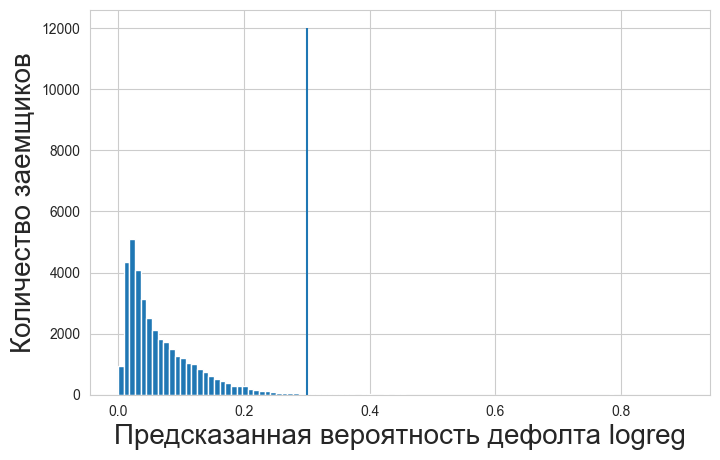

In [47]:
plt.figure(figsize=(8, 5))

plt.hist(test_probabilities_logreg, bins=100)
plt.vlines(0.3, 0, 12000)

plt.xlabel('Предсказанная вероятность дефолта logreg', fontsize=20)
plt.ylabel('Количество заемщиков', fontsize=20);

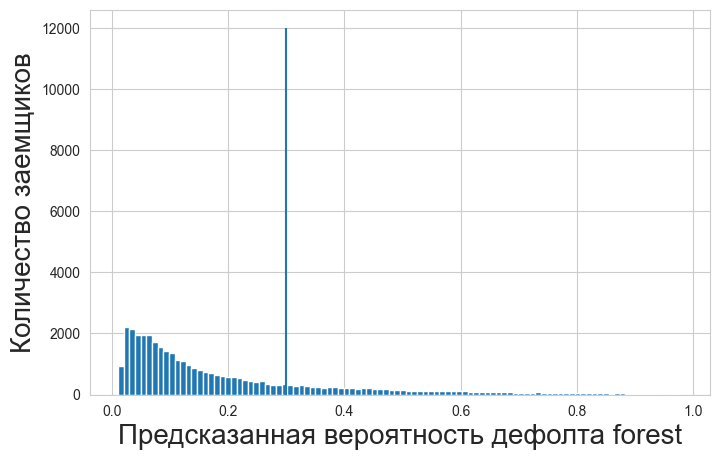

In [48]:
plt.figure(figsize=(8, 5))

plt.hist(test_probabilities_forest, bins=100)
plt.vlines(0.3, 0, 12000)

plt.xlabel('Предсказанная вероятность дефолта forest', fontsize=20)
plt.ylabel('Количество заемщиков', fontsize=20);

Распределение сконцентрировано на отрезке от `0` до `0.3` и лишь незначительная часть вероятностей превышает порог `0.5`. Из
этого можно предположить, что классификатор склонен классифицировать все
объекты скорее как `0`, игнорируя метку `1`. Это происходит потому, что меток `1` в обучающей выборке сильно меньше, чем меток `0`.

### Шаг 5.4. Выбор порога классификатора

На самом деле, при вызове метода **`predict()`** классификатор преобразует полученные вероятности в метки. По умолчанию для этого используется сравнение с порогом $0.5$: если вероятность объекта меньше порога, то этот объект относится к классу 0, если больше - к классу 1.  

По умолчанию классификатор использует порог $0.5$, чтобы из вероятностей принадлежности к классу сделать метки классов.  

**За что отвечает порог классификатора?**

Порог классификатора контролирует соотношение между количеством False positive и False negative. Если мы задаем слишком высокий порог классификатора, то он редко предсказывает 1, но часто 0, таким образом, увеличивается количество False negative и уменьшается количество False positive. Если же порог низкий - мы часто предсказываем 1, а 0 реже, значит увеличивается количество False positive и уменьшается False negative.

Что это значит в нашей задаче кредитного скоринга? Если порог высокий, то мы реже считаем клиентов подозрительными и чаще выдаем клиентам кредит. В этом случае банк может потерять много денег из-за невозвратов. Если же порог низкий, то мы чаще считаем клиентов подозрительными и выдаем мало кредитов. Очевидно, это тоже плохо, так как мы часто не выдаем кредиты честным клиентам, что отражается на прибыли банка.

Посмотрим на то, как влияет порог на матрицу сопряженности.  

In [49]:
higher_thershold = 0.7
alternative_test_predictions_1 = test_probabilities_logreg > higher_thershold


In [50]:
alternative_confusion_matrix_1 = pd.DataFrame(confusion_matrix(test_values, alternative_test_predictions_1))
alternative_confusion_matrix_1

,0,1
0,34941,32
1,2505,22


Действительно, количество ложно-отрицательных (False negative) срабатываний увеличилось, а количество ложно-положительных срабатываний (False positive) уменьшилось.

**Задание:** получите confusion matrix для уменьшенного значения порога 0.3

In [51]:
# 21. TODO
lower_thershold = 0.3
alternative_test_predictions_2 = test_probabilities_logreg > lower_thershold

alternative_confusion_matrix_2 = pd.DataFrame(confusion_matrix(test_values, alternative_test_predictions_2))
alternative_confusion_matrix_2

,0,1
0,34747,226
1,2375,152


In [52]:
# 22. TODO
# Получите confusion matrix для порогов: 0.3, 0.5, 0.7 для алгоритма Random Forest и выведите её.

treshold_1 = 0.3
treshold_2 = 0.5
treshold_3 = 0.7

alt_test_pred1 = test_probabilities_forest > treshold_1
alt_test_pred2 = test_probabilities_forest > treshold_2
alt_test_pred3 = test_probabilities_forest > treshold_3

alt_confusion_matrix1 = pd.DataFrame(confusion_matrix(test_values, alt_test_pred1))
alt_confusion_matrix2 = pd.DataFrame(confusion_matrix(test_values, alt_test_pred2))
alt_confusion_matrix3 = pd.DataFrame(confusion_matrix(test_values, alt_test_pred3))

In [53]:
alt_confusion_matrix1

,0,1
0,28899,6074
1,745,1782


In [54]:
alt_confusion_matrix2

,0,1
0,32890,2083
1,1360,1167


In [55]:
alt_confusion_matrix3

,0,1
0,34402,571
1,1988,539


### *Бонус:  ROC кривая классификатора

Если хотят сравнить метрики на разных наборах данных, обычно работают не с абсолютными значениями True Positive и False Positive, а с их долями:

* Доля ложноположительных срабатываний $\text{FPR} = \frac{FP}{FP + TN}$;
* Доля истинно положительных срабатываний $\text{TPR} = \frac{TP}{TP + FN}$.

Заметим, что $FP + TN$ дает общее число объектов класса $0$, а $TP + FN$ - общее число объектов класса $1$.

Одной из самых популярных метрик для задачи классификации является ROC кривая. ROC расшифровывается как *Receiver Operating Characteristic*. Эта кривая наглядно показывает зависимость доли истинно позитивных срабатываний (**TPR**) от доли ложно позитивных срабатываний (**FPR**) при изменении порога классификации.

Функция **roc_curve()** из **scikit-learn** позволяет получить координаты точек ROC кривой, а также значения порога **threshold**, при котором достигается соответствующие значения метрик **FPR** и **TPR**.

На вход функции **roc_curve()** необходимо передать два аргумента:
* истинные значения меток - *test_values*
* вероятности, предсказанные моделью - *test_probabilities*

In [56]:
# 23. TODO

false_positive_rates, true_positive_rates, threshold = roc_curve(test_values, test_probabilities_logreg)

Нарисуем кривую

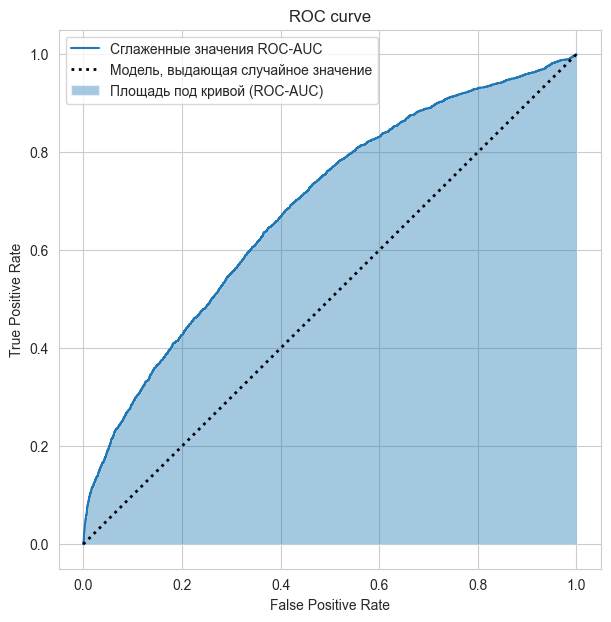

In [57]:
# создаём график
plt.figure(figsize=(7, 7))

# рисуем кривую
plt.plot(false_positive_rates, true_positive_rates, label='Сглаженные значения ROC-AUC')

# кривая, соответствующая случайному угадыванию
plt.plot([0, 1], [0, 1], color='k', lw=2, linestyle=':', label='Модель, выдающая случайное значение')

plt.title('ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.fill_between(false_positive_rates, true_positive_rates, step="mid", alpha=0.4, label='Площадь под кривой (ROC-AUC)')
plt.legend()
plt.show()

Чем ближе в целом кривая **ROC** к **левому верхнему** углу, тем лучше качество классификации.

Несмотря на наглядность, иногда требуется некоторое число, обобщающее весь
график. Для ROC кривой таким числом является "площадь под кривой" (**ROC-AUC**).

В **sklearn** есть специальная функция **roc_auc_score()** для подсчёта
площади под ROC-кривой.

In [58]:
from sklearn.metrics import roc_auc_score

Типичная шкала для **ROC-AUC** (часто все зависит от задачи):
* $0.90$ - $1.00$ отлично;
* $0.80$ - $0.90$ хорошо;
* $0.70$ - $0.80$ удовлетворительно;
* $0.60$ - $0.70$ плохо;
* $0.50$ - $0.60$ очень плохо;
* $0.00$ - $0.50$ классификатор перепутал метки.

Вычислите значения *roc_auc_value* для обеих моделей

In [59]:
# 24. TODO

roc_auc_value_logreg = roc_auc_score(test_values, test_probabilities_logreg)
roc_auc_value_forest = roc_auc_score(test_values, test_probabilities_forest)

print("ROC-AUC на тестовой выборке logreg:", roc_auc_value_logreg)
print("ROC-AUC на тестовой выборке forest:", roc_auc_value_forest)

ROC-AUC на тестовой выборке logreg: 0.6866081755804363
ROC-AUC на тестовой выборке forest: 0.8456878844328901


Выведите график ROC-AUC для алгоритма Random Forest. Попробуйте проанализировать параметры модели и добиться значения ROC-AUC ≥ 0.9

In [60]:
false_positive_rates, true_positive_rates, threshold = roc_curve(test_values, test_probabilities_forest)

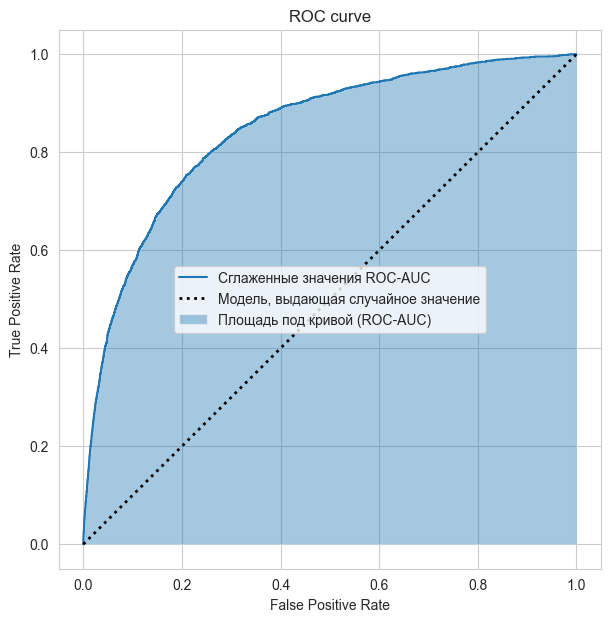

In [61]:
# 26. TODO

# создаём график
plt.figure(figsize=(7, 7))

# рисуем кривую
plt.plot(false_positive_rates, true_positive_rates, label='Сглаженные значения ROC-AUC')

# кривая, соответствующая случайному угадыванию
plt.plot([0, 1], [0, 1], color='k', lw=2, linestyle=':', label='Модель, выдающая случайное значение')

plt.title('ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.fill_between(false_positive_rates, true_positive_rates, step="mid", alpha=0.4, label='Площадь под кривой (ROC-AUC)')
plt.legend()
plt.show()

# Самостоятельная работа


## Пункт 3.

> Исследуйте другие модели для реализации классификации значений. Постарайтесь построить более точную модель, модель, имеющую ошибку, меньшую чем в рассматриваемых в борде (например, SVM, kNN). При невозможности получить более точную модель, используйте LLM инструменты для того чтобы это сделать (альтернативно: опишите с помощью LLM, почему это сделать невозможно).


In [62]:
from sklearn.ensemble import HistGradientBoostingClassifier

final_best_model = HistGradientBoostingClassifier(
    max_iter=600,              
    learning_rate=0.02,        
    max_leaf_nodes=45,         
    min_samples_leaf=25,      
    l2_regularization=5.0,     
    class_weight='balanced',    
    early_stopping=True,       
    random_state=42
)



In [63]:
final_best_model.fit(training_points, training_values)

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.02
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",600
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",45
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",25
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",5.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_d

In [64]:
test_probabilities = final_best_model.predict_proba(test_points)[:, 1]

In [65]:
false_positive_rates, true_positive_rates, threshold = roc_curve(test_values, test_probabilities)

In [66]:
roc_auc_value_svc = roc_auc_score(test_values, test_probabilities)

print("ROC-AUC на тестовой выборке SVC:", roc_auc_value_svc)

ROC-AUC на тестовой выборке SVC: 0.8629213382326449


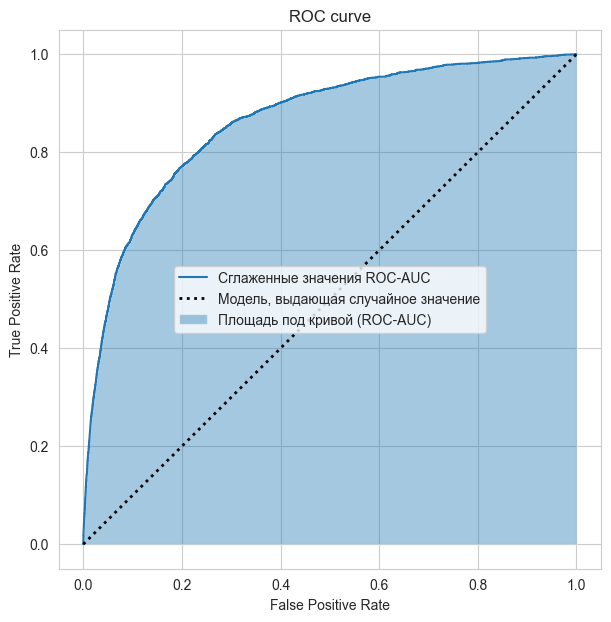

In [67]:
# 26. TODO

# создаём график
plt.figure(figsize=(7, 7))

# рисуем кривую
plt.plot(false_positive_rates, true_positive_rates, label='Сглаженные значения ROC-AUC')

# кривая, соответствующая случайному угадыванию
plt.plot([0, 1], [0, 1], color='k', lw=2, linestyle=':', label='Модель, выдающая случайное значение')

plt.title('ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.fill_between(false_positive_rates, true_positive_rates, step="mid", alpha=0.4, label='Площадь под кривой (ROC-AUC)')
plt.legend()
plt.show()